--- Part 1: Building a Simple Feedforward Neural Network ---

Original FNN training data shape: (60000, 28, 28)
Original FNN test data shape: (10000, 28, 28)
Flattened & Normalized FNN training data shape: (60000, 784)
Flattened & Normalized FNN test data shape: (10000, 784)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- FNN Model Summary ---



--- Training FNN Model ---

--- Evaluating FNN Model ---
FNN Test Loss: 0.3400
FNN Test Accuracy: 0.8773

--- FNN Classification Report ---
              precision    recall  f1-score   support

           0       0.81      0.85      0.83      1000
           1       0.99      0.97      0.98      1000
           2       0.80      0.77      0.78      1000
           3       0.90      0.86      0.88      1000
           4       0.70      0.90      0.79      1000
           5       0.97      0.96      0.97      1000
           6       0.75      0.58      0.66      1000
           7       0.92      0.97      0.95      1000
           8       0.97      0.97      0.97      1000
           9       0.97      0.94      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


--- FNN Confusion Matrix ---


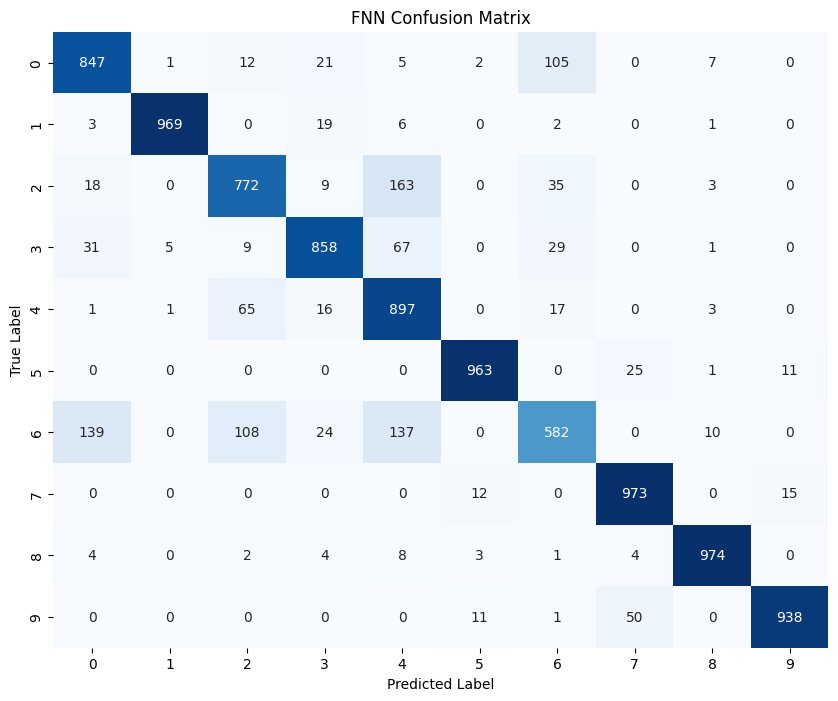

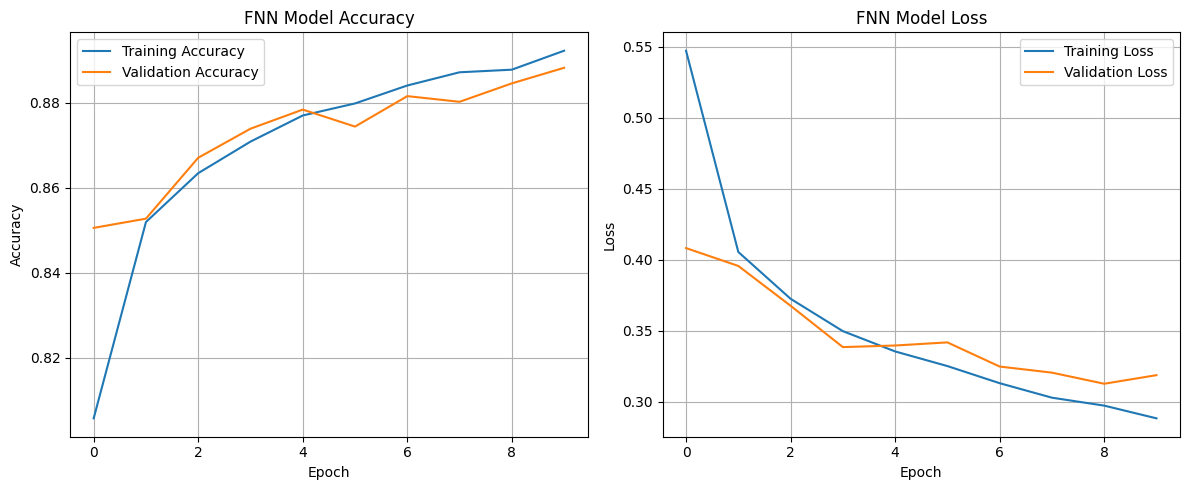


--- Part 2: Implementing a CNN ---

Original CNN training data shape: (60000, 28, 28)
Original CNN test data shape: (10000, 28, 28)
Reshaped & Normalized CNN training data shape: (60000, 28, 28, 1)
Reshaped & Normalized CNN test data shape: (10000, 28, 28, 1)

--- CNN Model Summary ---


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Training CNN Model ---

--- Evaluating CNN Model ---
CNN Test Loss: 0.0269
CNN Test Accuracy: 0.9925

--- CNN Classification Report ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


--- CNN Confusion Matrix ---


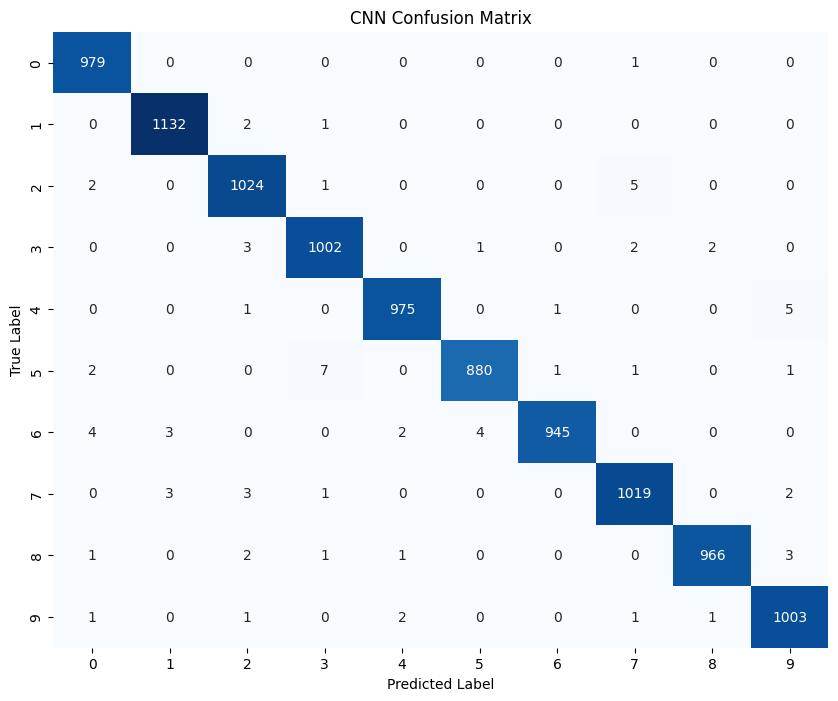

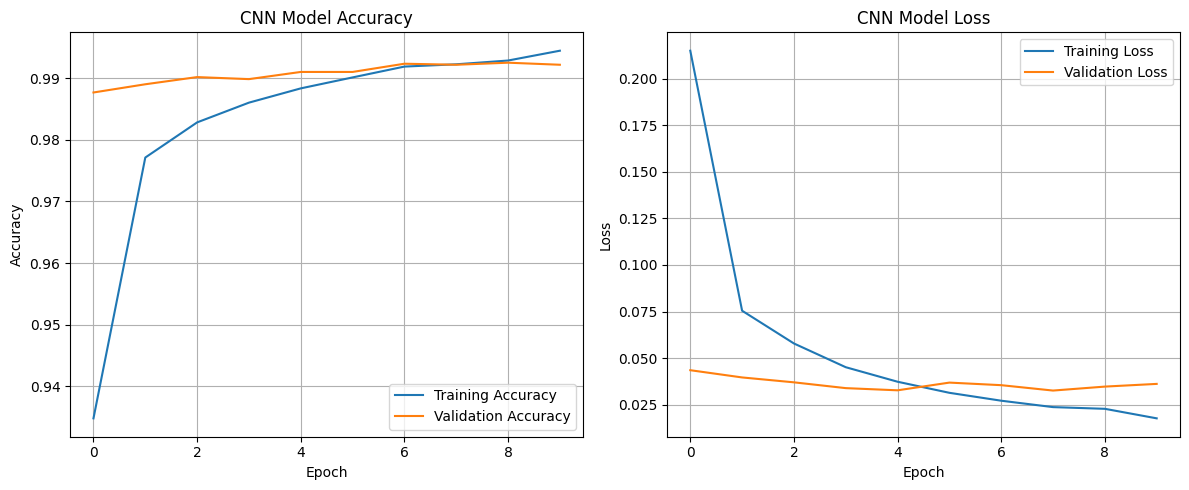


--- Sample CNN Predictions ---


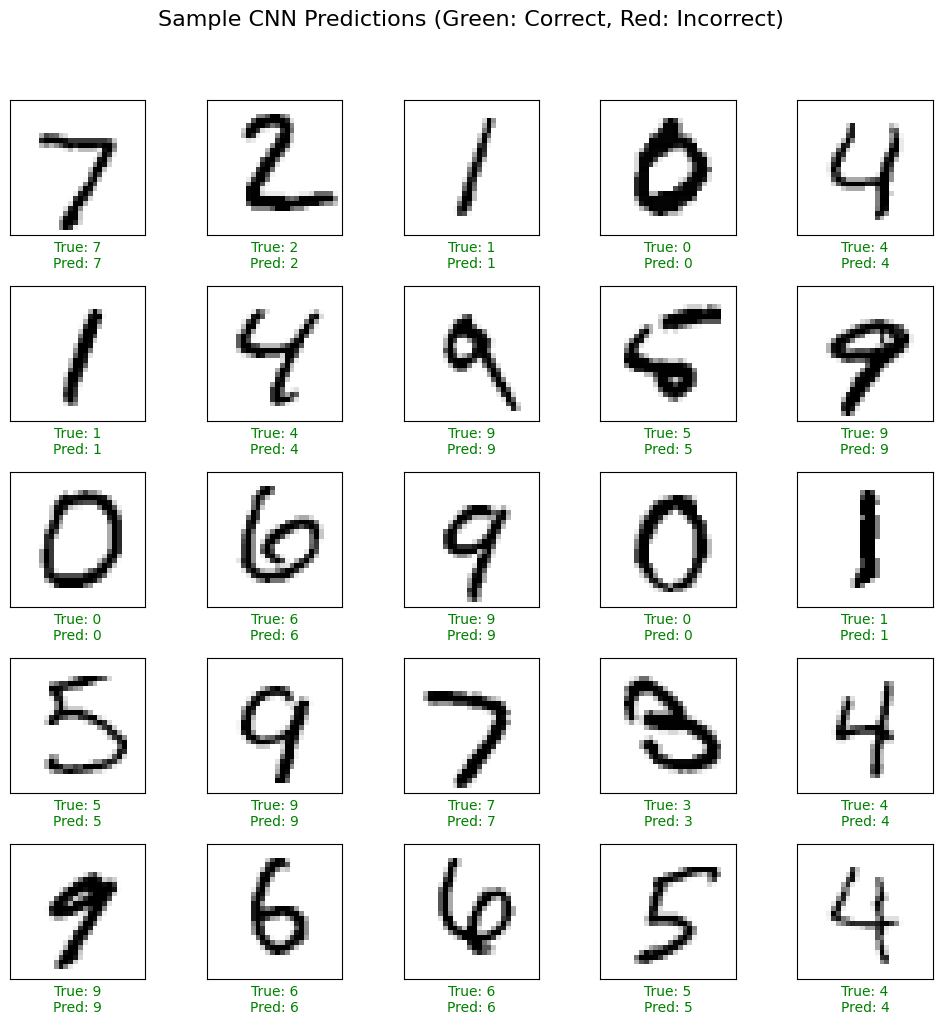

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist, fashion_mnist
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

tf.keras.utils.disable_interactive_logging()

print("--- Part 1: Building a Simple Feedforward Neural Network ---")

(x_train_fnn, y_train_fnn), (x_test_fnn, y_test_fnn) = fashion_mnist.load_data()
print(f"\nOriginal FNN training data shape: {x_train_fnn.shape}")
print(f"Original FNN test data shape: {x_test_fnn.shape}")

x_train_fnn_flat = x_train_fnn.reshape(-1, 28 * 28)
x_test_fnn_flat = x_test_fnn.reshape(-1, 28 * 28)

x_train_fnn_norm = x_train_fnn_flat / 255.0
x_test_fnn_norm = x_test_fnn_flat / 255.0
print(f"Flattened & Normalized FNN training data shape: {x_train_fnn_norm.shape}")
print(f"Flattened & Normalized FNN test data shape: {x_test_fnn_norm.shape}")

model_fnn = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_fnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("\n--- FNN Model Summary ---")
model_fnn.summary()

print("\n--- Training FNN Model ---")
history_fnn = model_fnn.fit(x_train_fnn_norm, y_train_fnn, epochs=10, validation_split=0.1, verbose=1)

print("\n--- Evaluating FNN Model ---")
loss_fnn, accuracy_fnn = model_fnn.evaluate(x_test_fnn_norm, y_test_fnn, verbose=0)
print(f"FNN Test Loss: {loss_fnn:.4f}")
print(f"FNN Test Accuracy: {accuracy_fnn:.4f}")

y_pred_fnn = np.argmax(model_fnn.predict(x_test_fnn_norm), axis=-1)
print("\n--- FNN Classification Report ---")
print(classification_report(y_test_fnn, y_pred_fnn))
print("\n--- FNN Confusion Matrix ---")
cm_fnn = confusion_matrix(y_test_fnn, y_pred_fnn)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_fnn, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("FNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_fnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_fnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('FNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(history_fnn.history['loss'], label='Training Loss')
plt.plot(history_fnn.history['val_loss'], label='Validation Loss')
plt.title('FNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n--- Part 2: Implementing a CNN ---")

(x_train_cnn, y_train_cnn), (x_test_cnn, y_test_cnn) = mnist.load_data()
print(f"\nOriginal CNN training data shape: {x_train_cnn.shape}")
print(f"Original CNN test data shape: {x_test_cnn.shape}")

x_train_cnn = x_train_cnn.reshape(x_train_cnn.shape[0], 28, 28, 1)
x_test_cnn = x_test_cnn.reshape(x_test_cnn.shape[0], 28, 28, 1)

x_train_cnn = x_train_cnn.astype('float32') / 255.0
x_test_cnn = x_test_cnn.astype('float32') / 255.0
print(f"Reshaped & Normalized CNN training data shape: {x_train_cnn.shape}")
print(f"Reshaped & Normalized CNN test data shape: {x_test_cnn.shape}")
num_classes_cnn = 10

model_cnn = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes_cnn, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("\n--- CNN Model Summary ---")
model_cnn.summary()

print("\n--- Training CNN Model ---")
history_cnn = model_cnn.fit(x_train_cnn, y_train_cnn, epochs=10, validation_split=0.1, verbose=1)

print("\n--- Evaluating CNN Model ---")
loss_cnn, accuracy_cnn = model_cnn.evaluate(x_test_cnn, y_test_cnn, verbose=0)
print(f"CNN Test Loss: {loss_cnn:.4f}")
print(f"CNN Test Accuracy: {accuracy_cnn:.4f}")

y_pred_cnn = np.argmax(model_cnn.predict(x_test_cnn), axis=-1)
print("\n--- CNN Classification Report ---")
print(classification_report(y_test_cnn, y_pred_cnn))
print("\n--- CNN Confusion Matrix ---")
cm_cnn = confusion_matrix(y_test_cnn, y_pred_cnn)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n--- Sample CNN Predictions ---")
class_names_mnist = [str(i) for i in range(10)]
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test_cnn[i].reshape(28, 28), cmap=plt.cm.binary)
    true_label = y_test_cnn[i]
    predicted_label = y_pred_cnn[i]
    color = 'green' if true_label == predicted_label else 'red'
    plt.xlabel(f"True: {class_names_mnist[true_label]}\nPred: {class_names_mnist[predicted_label]}", color=color)
plt.suptitle("Sample CNN Predictions (Green: Correct, Red: Incorrect)", y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
